In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

# Deep Neural Networks 
## Session 01

## Implementation of MP Neuron.

<img src='../../prasami_images/prasami_color_tutorials_small.png' width='400' alt="By Pramod Sharma : pramod.sharma@prasami.com" align="left"/>

## 1. Import Statements
Import all the libraries.

In [2]:
###-----------------
### Import libraries
###-----------------
from pathlib import Path  # Import Path for file system path operations and management
import numpy as np  # Import NumPy for numerical computations and array operations
import pandas as pd  # Import Pandas for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive visualizations

from sklearn.model_selection import train_test_split  # Import function to split dataset into training and testing subsets
from sklearn.metrics import accuracy_score  # Import function to calculate various metric

## 2. Setup Global Parameters

In [3]:
###------------------
### Global Parameters
###------------------

# Directories
#inpDir = '../../input' 
inpDir = Path('..') / '..' / 'input'
# outDir = '../output'
outDir = Path('..') / 'output'


RANDOM_STATE = 24 
np.random.seed(RANDOM_STATE) # Set Random Seed for reproducible  results

TEST_SIZE  = 0.2 # Size of test data

# Parameters for plotting
params = {'legend.fontsize': 'medium',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'large',
          'axes.titlesize':'large',
          'xtick.labelsize':'medium',
          'ytick.labelsize':'medium'
         }

CMAP = plt.cm.coolwarm

plt.rcParams.update(params)

plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

## 3. Load Data Set

<div class="alert alert-block alert-info" style="font-family: Arial; font-size:1.1em;">
This data is generated from SKLearn Breast Cancer data.
</div>

In [4]:
# read CSV from the disk
data_df = pd.read_csv(inpDir/ 'breast_cancer_mod.csv')
data_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,1,0,0,1,1,0
1,0,1,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
2,0,1,0,0,0,0,0,0,0,1,...,1,0,1,0,1,1,0,1,1,0
3,0,1,0,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,1,1,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,1,0


In [5]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   mean radius              569 non-null    int64
 1   mean texture             569 non-null    int64
 2   mean perimeter           569 non-null    int64
 3   mean area                569 non-null    int64
 4   mean smoothness          569 non-null    int64
 5   mean compactness         569 non-null    int64
 6   mean concavity           569 non-null    int64
 7   mean concave points      569 non-null    int64
 8   mean symmetry            569 non-null    int64
 9   mean fractal dimension   569 non-null    int64
 10  radius error             569 non-null    int64
 11  texture error            569 non-null    int64
 12  perimeter error          569 non-null    int64
 13  area error               569 non-null    int64
 14  smoothness error         569 non-null    int64
 15  compactness error

In [6]:
data_df.isnull().sum().sum()  # Check for missing values

np.int64(0)

In [7]:
data_df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

###  Class Distribution
212 - Malignant, 357 - Benign

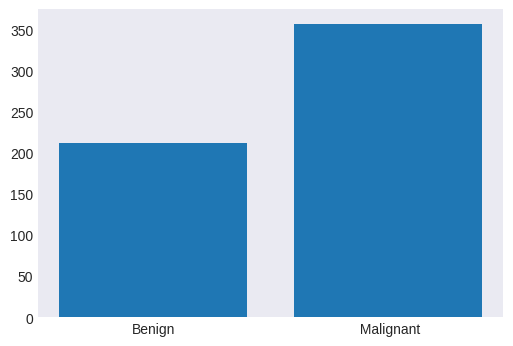

In [8]:
# create list of labels
class_names = [' Malignant', 'Benign']

# instantiate figure and axis
fig, ax = plt.subplots(figsize=(6,4))

# plot bars on the axis
ax.bar(data_df['target'].value_counts().index, data_df['target'].value_counts().values)

# Set custom x-axis tick labels
ax.set_xticks(data_df['target'].value_counts().index)

# Add label text
ax.set_xticklabels(class_names)

ax.grid();

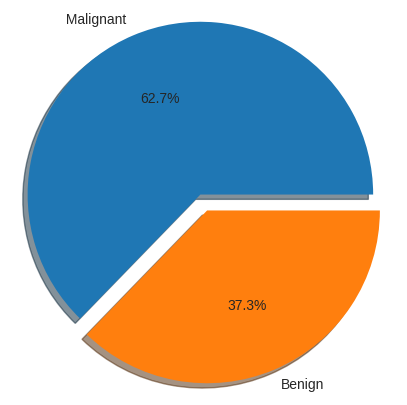

In [9]:
fig, ax = plt.subplots(figsize = (5,5))

explode = (0, 0.1)  # only "explode" the 2nd slice (i.e. '1')

ax.pie(data_df['target'].value_counts(), 
       explode=explode, 
       labels=class_names, autopct='%1.1f%%',
       shadow=True, startangle=0)

ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.show()

In [10]:
features = data_df.drop('target', axis = 1)
labels = data_df['target']

In [11]:
# Split X and y in train and test sets
X_train, X_test, y_train, y_test = train_test_split(features,
                                                    labels, 
                                                    test_size=TEST_SIZE, # proportion to include in the test split
                                                    stratify = labels,  # split in a stratified fashion, using this as the class labels
                                                    random_state=RANDOM_STATE) # set the random state

# what does shape look like
print (X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(455, 30) (455,) (114, 30) (114,)


In [12]:
# Verify all features are binary (0/1)
assert (X_train.isin([0, 1]).all().all()), "Features must be binary for MP Neuron"

# Over to MP Neurons
<img src='../../images/dnn_nb_s01_fig1.jpg' width='350' />

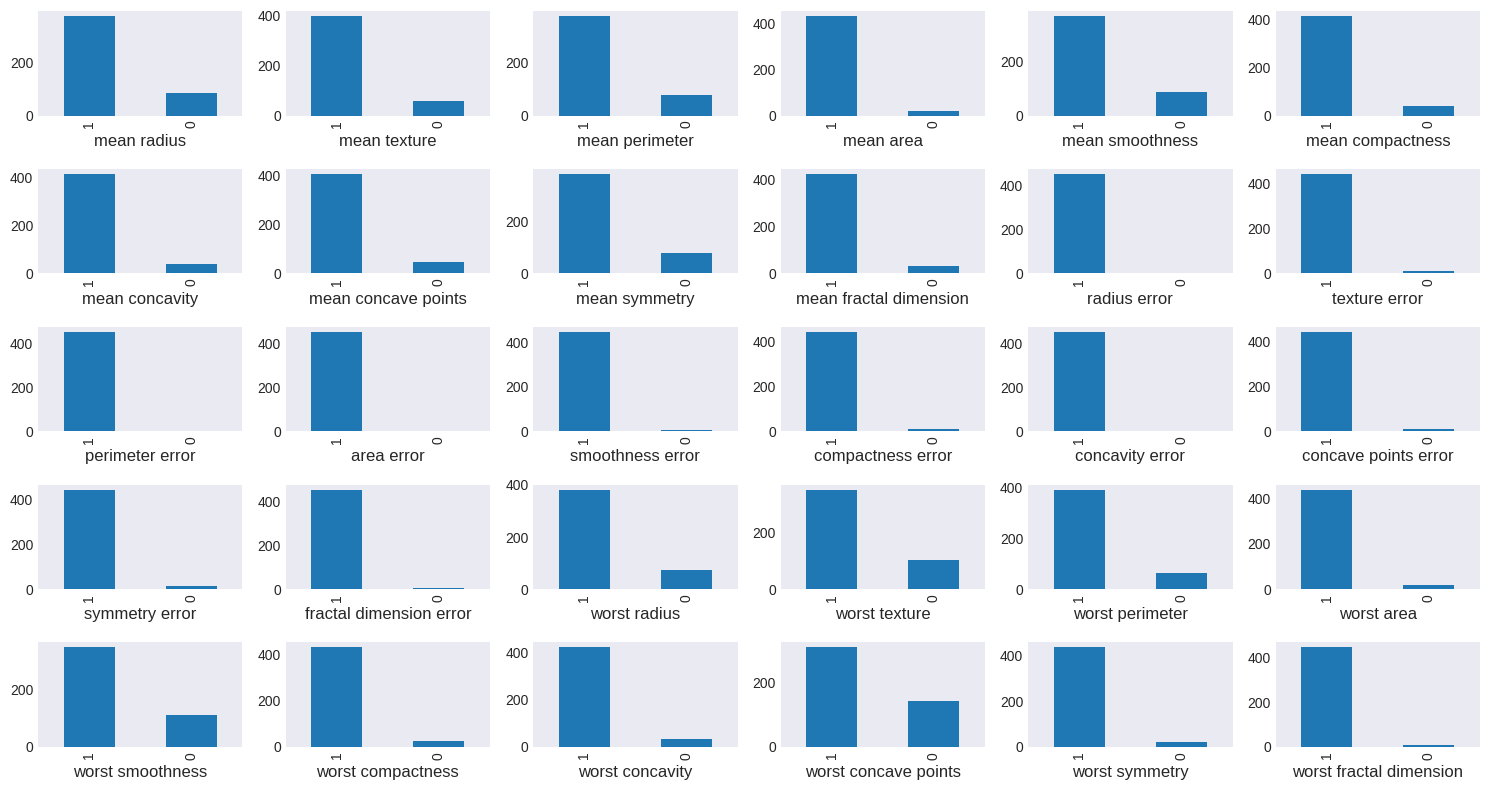

In [13]:
# Plot Training data

fig, axes = plt.subplots(5,6, figsize = (15, 8)) # 5 x 6 = 30 columns

axes = axes.ravel() # convert 2d Array to single dimension

# Iterate all columns and plot individually
for i, col in enumerate(X_train.columns):
    
    ax = X_train[col].value_counts().plot(ax=axes[i], kind='bar');
    
    ax.grid()

plt.tight_layout()

## Training Data

In [14]:
 # create a column with sums
X_train['total'] = X_train.astype(np.int16).sum(axis=1) # convert to integer from object

X_train['target'] = y_train # target column from y_train

X_train.sort_values('total', inplace = True) # sort the values as per total

X_train.head()


'''Note: Adding total and target back to X_train is generally not recommended 
as it can lead to data leakage and overfitting. 
Ok for the purpose of this example.'''

'Note: Adding total and target back to X_train is generally not recommended \nas it can lead to data leakage and overfitting. \nOk for the purpose of this example.'

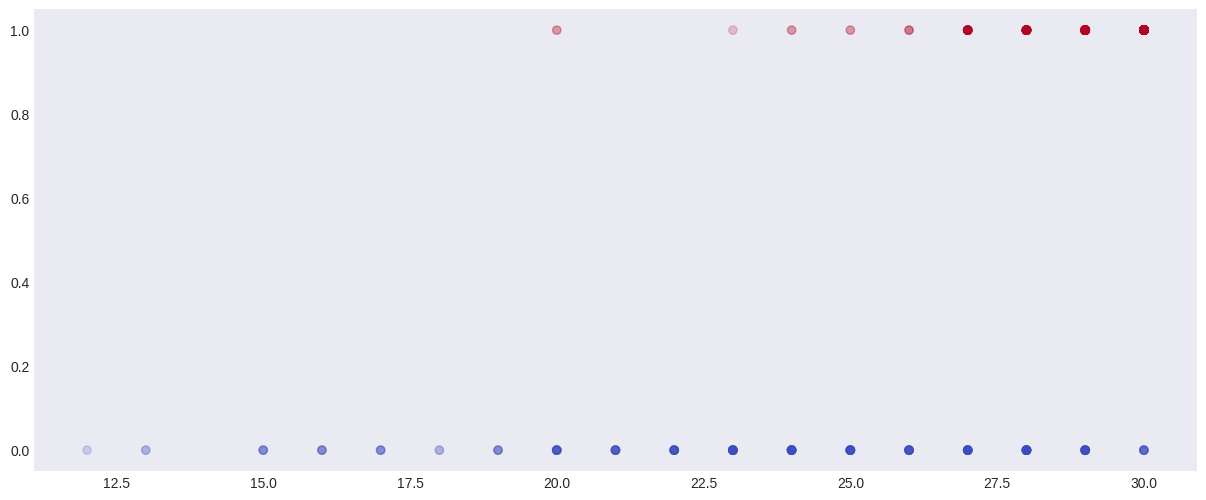

In [15]:
plt.scatter(X_train['total'], X_train['target'], 
            c=X_train['target'],  # Color by target values
            cmap=CMAP,      
            alpha=0.2)
plt.grid()

## Test Data

In [16]:
# Repeat the above steps with test dataset
X_test['total'] = X_test.astype(np.int16).sum(axis=1)

X_test['target'] = y_test

X_test.sort_values('total', inplace = True)

X_test.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,total,target
3,0,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,1,14,0
4,0,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,1,1,14,0
12,0,0,0,1,1,0,1,1,0,1,...,0,1,1,0,0,0,0,1,16,0
18,1,1,1,1,0,0,0,1,1,0,...,1,1,0,0,0,0,0,0,18,0
35,0,1,0,0,1,1,0,0,1,1,...,0,0,0,1,1,0,1,1,20,0


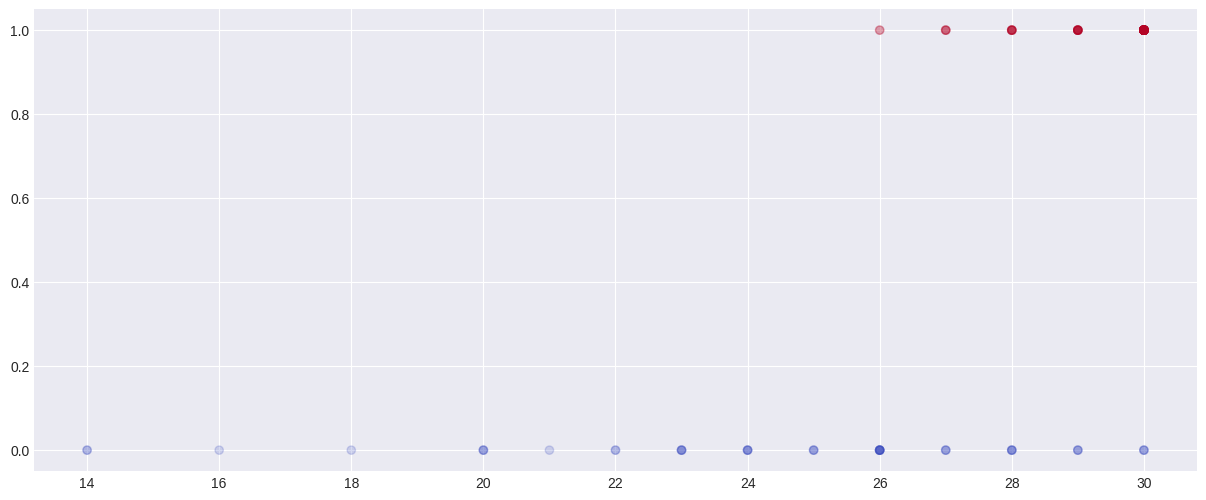

In [17]:
plt.scatter(X_test['total'], X_test['target'],
            c=X_test['target'],  # Color by target values
            cmap=CMAP,      
            alpha=0.2);

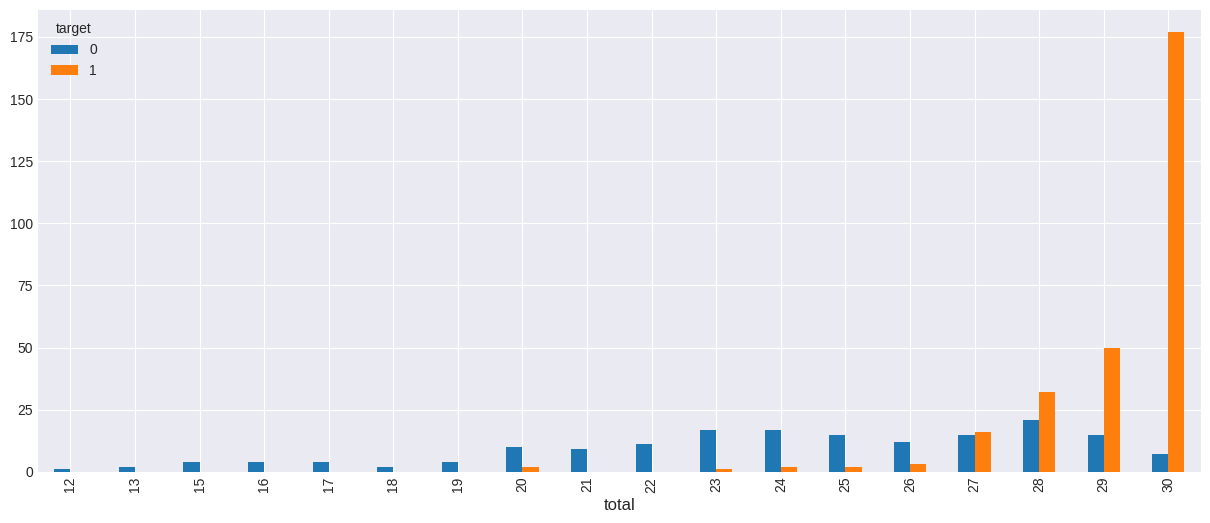

In [18]:
# plot Count of totals in the train set
tmp_df = X_train.groupby(['total', 'target']).agg({'target': 'count'}) # Create a tmp DataFrame

tmp_df.columns = ['count'] # rename column
2
tmp_df.reset_index(inplace = True) # reset index helps

tmp_df.pivot(index='total', columns='target', values='count').plot(kind = 'bar'); # create a pivot and plot

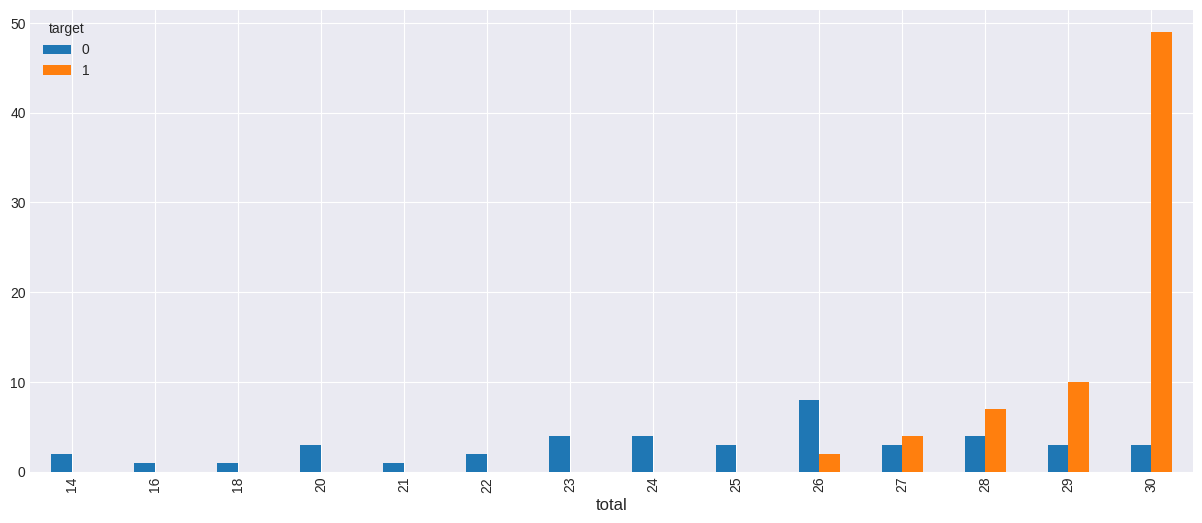

In [19]:
# repeat for test set

tmp_df = X_test.groupby(['total', 'target']).agg({'target': 'count'})

tmp_df.columns = ['count']

tmp_df.reset_index(inplace = True)

tmp_df.pivot(index='total', columns='target', values='count').plot(kind = 'bar');

In [20]:
X_train.shape[1], features.shape[1]

(32, 30)

Note: In real world, we would loop for features.shape[1] + 1.
This is just for the purpose of understanding how the MP Neuron model works.

In [ ]:
# Calculate accuracy
accuracy = {}

# loop over the rows

for b in range(X_train.shape[1]):
    
    X_train['y_pred'] = X_train['total'] >= b # make prediction based on total
    
    accuracy[b] = accuracy_score( y_true=X_train['target'], y_pred=X_train['y_pred']) # calculate accuracy

In [22]:
best_b = max(accuracy, key = accuracy.get) # find best accuracy

print('Optimal value of b is', best_b)

print('Highest accuracy is: {0:4.2f} %'.format(accuracy[best_b] *100))

Optimal value of b is 27
Highest accuracy is: 85.05 %


In [23]:
# Using best b calculate accuracy on test set

X_test['y_pred'] = X_test['total'] >= best_b

test_accuracy = accuracy_score(y_true=X_test['target'], y_pred=X_test['y_pred'] )

print ('Accuracy of testing is: {0:4.2f} %'.format(test_accuracy*100))

Accuracy of testing is: 86.84 %


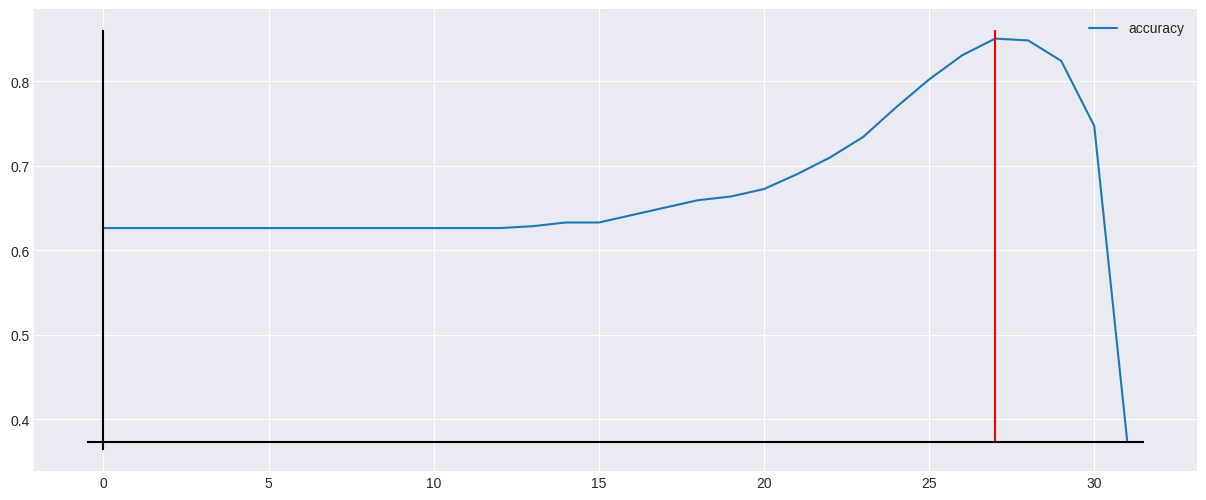

In [24]:
# plot results
ax = pd.DataFrame([accuracy], index = ['accuracy']).T.plot()

ax.vlines( x=best_b, ymin=min(accuracy.values()), ymax=accuracy[best_b]+0.01, colors='r')

ax.vlines( x = 0, ymin=min(accuracy.values())-0.01, ymax=accuracy[best_b]+0.01, colors='k')

ax.hlines( y=min(accuracy.values()), xmin=min(accuracy.keys())-0.5, xmax=max(accuracy.keys())+0.5, colors='k');